# CN-Star Detection: Cluster-Conditional Binary Classification\n
\n
**Testing three improvements over the baseline MLP classifier:**\n
\n
| Change | Description | Goal |\n
|---|---|---|\n
| **A** | Cluster-stratified negative sampling | Force model to learn within-cluster differences |\n
| **B** | Cluster-conditional scoring (z-score) | Remove cross-cluster parameter bias from ranking |\n
| **C** | Delta-only features | Drop teff/logg/feh, use only cluster-relative features |\n
\n
**Key insight**: CN-enhanced stars are defined as anomalous *within their stellar class*. A cool star with normal CN for its Teff should NOT outrank a hot star with exceptional CN for its Teff.

## 1. Setup & Imports

In [1]:
import sys, os, pickle, time, copy, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

_p = Path.cwd().resolve()
for _ in range(5):
    if (_p / 'Deep' / 'data.py').exists():
        break
    _p = _p.parent
PROJECT_ROOT = _p
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 10})

import torch
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import spearmanr

from BinaryClassifier import augment_spectra, BinaryTrainer
from BinaryClassifier.pipeline import slice_wave_range, WAVE_START, WAVE_END
from Deep.data import (
    SpectraDataset, load_spectra_data,
    compute_physics_features_masked_cluster,
    compute_physics_features,
)
from Deep.augmentation import load_gcs_spectra
from Deep.spectra_io import label_stars_by_cn_catalog

print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')
print('All imports OK')

Project root: D:\资料\2026大创\Lamost
Device: cuda
All imports OK


## 2. Data Loading & Feature/Cluster Computation

In [2]:
print('Loading LAMOST spectra...')
common_wave_full = np.arange(3710.0, 8890.0, 1.0)

dataset_full = load_spectra_data(
    stars_csv=str(PROJECT_ROOT / 'stars.csv'),
    spectra_folder=str(PROJECT_ROOT / 'dr13_new'),
    cn_catalogs=[str(PROJECT_ROOT / 'FT_cands.csv')],
    common_wave=common_wave_full, seg_width=200.0,
    verbose=False,
)

X_sliced, wave = slice_wave_range(dataset_full.X, common_wave_full, WAVE_START, WAVE_END)
dataset = SpectraDataset(
    X=X_sliced, y=dataset_full.y.copy(),
    meta=dataset_full.meta.copy(), wave=wave,
)
print(f'Dataset: {dataset.X.shape[0]} spectra x {dataset.X.shape[1]} pixels')
print(f'FT_cands (y=1): {dataset.n_positive}  |  Unlabeled (y=-1): {dataset.n_unlabeled}')

Loading LAMOST spectra...
Dataset: 33512 spectra x 1201 pixels
FT_cands (y=1): 15  |  Unlabeled (y=-1): 33497


In [3]:
print('Computing masked-band clustering + physics features...')
phys_result = compute_physics_features_masked_cluster(
    dataset, n_clusters=45, k_neighbors=180, n_pca=3, random_seed=42,
)
dataset_phys = phys_result['dataset']  # SpectraDataset with 12-D features
cluster_labels = phys_result['cluster_labels']  # shape (33512,)
n_clusters = phys_result['n_clusters']

# Feature names
feat_names = ['teff','logg','feh','CN3839','CN4142','CH4300',
              'delta_CN3839','delta_CN4142','delta_CH4300',
              'pca_1','pca_2','pca_3']
print(f'Physics features: {dataset_phys.X.shape}')
print(f'Clusters: {n_clusters}')
print(f'Feature names: {feat_names}')

Computing masked-band clustering + physics features...
  Masked-cluster: 45 clusters (PCA-25 on masked spectra)
Physics features: (33512, 12)
Clusters: 45
Feature names: ['teff', 'logg', 'feh', 'CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'pca_1', 'pca_2', 'pca_3']


In [4]:
# Build validation sets: CNstar + GCS
print('Building validation sets...')

# CNstar: match to dataset by coordinates
cnstar_labeled, _ = label_stars_by_cn_catalog(
    stars_df=dataset.meta.copy(),
    cn_catalogs=[str(PROJECT_ROOT / 'CNstar.csv')],
    tolerance_arcsec=1.0, positive_label=1, unlabeled_value=-1,
)
cnstar_mask = cnstar_labeled['label'].values == 1

# GCS: load separately
gcs_raw, _ = load_gcs_spectra(str(PROJECT_ROOT / 'GCS'), common_wave_full)
from Deep.data import normalize_datacube_segment
gcs_norm = normalize_datacube_segment(gcs_raw, common_wave_full, seg_width=200.0, deg=2, show_progress=False)
X_gcs_sliced, _ = slice_wave_range(gcs_norm, common_wave_full, WAVE_START, WAVE_END)

# GCS physics features
gcs_cat = pd.read_csv(str(PROJECT_ROOT / 'GCS.csv'))
n_gcs = len(X_gcs_sliced)
gcs_meta = pd.DataFrame({
    'label': [1]*n_gcs, 'teff': gcs_cat['Teff'].values[:n_gcs],
    'logg': gcs_cat['logg'].values[:n_gcs], 'feh': gcs_cat['[Fe/H]'].values[:n_gcs],
})
gcs_ds = SpectraDataset(X=X_gcs_sliced, y=np.ones(n_gcs), meta=gcs_meta, wave=wave)
gcs_phys = compute_physics_features(gcs_ds, n_pca=3, random_seed=42)
X_gcs_phys = gcs_phys.X

print(f'CNstar: {cnstar_mask.sum()} spectra')
print(f'GCS:    {len(X_gcs_phys)} spectra (physics features)')

Building validation sets...
CNstar: 92 spectra
GCS:    29 spectra (physics features)


In [5]:
# Build train/neg/val splits
rng = np.random.RandomState(42)

# Exclude known positives from negative pool
exclude_mask = np.zeros(len(dataset_phys), dtype=bool)
exclude_mask[dataset_phys.y == 1] = True       # FT_cands
exclude_mask[cnstar_mask] = True                 # CNstar

# FT_cands seed in physics space
X_ft_phys = dataset_phys.X[dataset_phys.y == 1]
n_ft = len(X_ft_phys)

# Augment FT_cands
X_ft_aug, _ = augment_spectra(
    X_ft_phys, dataset_phys.wave,
    n_noise=12, n_rv=6, n_tilt=4, n_mixup=8, n_depth=6,
    noise_std=0.0025, random_seed=42,
)

# Negative pool (unlabeled only)
neg_pool = dataset_phys.X[~exclude_mask]
neg_clusters = cluster_labels[~exclude_mask]

# Positive cluster assignments
pos_clusters = cluster_labels[dataset_phys.y == 1]

# Train/val split (10% val)
n_val_pos = max(int(len(X_ft_aug) * 0.1), 5)
val_pos_idx = rng.choice(len(X_ft_aug), n_val_pos, replace=False)
train_pos_mask = np.ones(len(X_ft_aug), dtype=bool)
train_pos_mask[val_pos_idx] = False
X_train_pos = X_ft_aug[train_pos_mask]

n_val_neg = n_val_pos
val_neg_idx = rng.choice(len(neg_pool), n_val_neg, replace=False)
X_val = np.vstack([X_ft_aug[val_pos_idx], neg_pool[val_neg_idx]])
y_val = np.concatenate([np.ones(n_val_pos), np.zeros(n_val_neg)]).astype(np.float32)

# Validation sets (all-positive)
X_cnstar_phys = dataset_phys.X[cnstar_mask]

print(f'X_train_pos:  {X_train_pos.shape}')
print(f'neg_pool:     {neg_pool.shape}')
print(f'X_val:        {X_val.shape}')
print(f'X_cnstar:     {X_cnstar_phys.shape}')
print(f'X_gcs:        {X_gcs_phys.shape}')
print(f'pos_clusters: {np.unique(pos_clusters).tolist()}')

X_train_pos:  (500, 12)
neg_pool:     (33420, 12)
X_val:        (110, 12)
X_cnstar:     (92, 12)
X_gcs:        (29, 12)
pos_clusters: [0, 1, 2, 3, 11, 14, 19, 20, 29, 36]


## 3. Helper Functions\n
\n
Training, evaluation, and scoring utilities shared across experiments.

In [6]:
def train_single_model(X_pos, X_neg, X_val, y_val, seed, input_dim, device='cpu', verbose=False):
    """Train one BinaryClassifier with given pos/neg sets."""
    trainer = BinaryTrainer(
        input_dim=input_dim, latent_dim=64, dropout=0.35,
        encoder_type='mlp', learning_rate=1e-4, weight_decay=1e-5,
        pos_weight=1.0, mixup_alpha=0.2, n_epochs=80,
        early_stopping_patience=15, random_seed=seed,
        device=device, save_dir='BinaryClassifier/checkpoints',
    )
    model = trainer.train(X_pos, X_neg, X_val, y_val, verbose=verbose)
    return model, trainer.history


def train_ensemble_with_sampler(
    X_pos, neg_pool, neg_clusters, pos_clusters,
    X_val, y_val, n_models=5, base_seed=42,
    in_cluster_ratio=0.7, input_dim=12, device='cpu', verbose=True,
):
    """Train ensemble with custom negative sampling strategy.
    
    Parameters
    ----------
    in_cluster_ratio : float
        Fraction of negatives sampled from same clusters as positives.
        1.0 = all negatives from pos clusters (max contrastive)
        0.0 = random sampling (baseline)
    """
    rng = np.random.RandomState(base_seed)
    models, histories = [], []
    n_neg_per_model = len(X_pos)
    unique_pos_clusters = np.unique(pos_clusters)
    
    for i in range(n_models):
        seed = base_seed + i * 100
        
        # Sample negatives
        n_in = int(n_neg_per_model * in_cluster_ratio)
        n_out = n_neg_per_model - n_in
        
        in_mask = np.isin(neg_clusters, unique_pos_clusters)
        in_idx = np.where(in_mask)[0]
        out_idx = np.where(~in_mask)[0]
        
        n_in = min(n_in, len(in_idx))
        n_out = min(n_out, len(out_idx))
        
        sampled_in = rng.choice(in_idx, n_in, replace=False) if n_in > 0 else np.array([], dtype=int)
        sampled_out = rng.choice(out_idx, n_out, replace=False) if n_out > 0 else np.array([], dtype=int)
        neg_indices = np.concatenate([sampled_in, sampled_out])
        rng.shuffle(neg_indices)
        
        X_neg = neg_pool[neg_indices]
        
        if verbose:
            print(f'  Model {i+1}/{n_models} (seed={seed}): {n_in} in-cluster + {n_out} out-cluster negatives')
        
        model, hist = train_single_model(
            X_pos, X_neg, X_val, y_val, seed, input_dim, device, verbose=False,
        )
        models.append(model)
        histories.append(hist)
    
    return models, histories


def ensemble_predict(models, X, batch_size=512, device='cpu'):
    """Average predictions across ensemble."""
    probs = np.array([m.predict(X, batch_size, device) for m in models])
    return probs.mean(axis=0), probs.std(axis=0)


def cluster_z_score(probs, cluster_labels):
    """Convert raw probabilities to per-cluster z-scores."""
    z = np.zeros_like(probs)
    for cid in np.unique(cluster_labels):
        mask = cluster_labels == cid
        c_probs = probs[mask]
        mu, sigma = c_probs.mean(), c_probs.std()
        if sigma > 1e-8 and len(c_probs) >= 5:
            z[mask] = (c_probs - mu) / sigma
    return z


def cluster_percentile_rank(probs, cluster_labels):
    """Per-cluster percentile rank (0-100)."""
    ranks = np.zeros_like(probs)
    for cid in np.unique(cluster_labels):
        mask = cluster_labels == cid
        c_probs = probs[mask]
        if len(c_probs) >= 2:
            from scipy.stats import percentileofscore
            for idx in np.where(mask)[0]:
                ranks[idx] = percentileofscore(c_probs, probs[idx])
    return ranks


def evaluate_on_test(models, X_test, batch_size=512, device='cpu'):
    """Evaluate ensemble on a test set."""
    probs, stds = ensemble_predict(models, X_test, batch_size, device)
    return {
        'probs': probs, 'stds': stds,
        'mean_prob': float(probs.mean()),
        'median_prob': float(np.median(probs)),
    }

print('Helper functions defined.')

Helper functions defined.


## 4. Baseline — Random Negative Sampling (in_cluster_ratio=0.0)

In [7]:
print('Training BASELINE (random negatives, in_cluster_ratio=0.0)...')
t0 = time.time()

models_baseline, hist_baseline = train_ensemble_with_sampler(
    X_train_pos, neg_pool, neg_clusters, pos_clusters,
    X_val, y_val, n_models=5, base_seed=42,
    in_cluster_ratio=0.0, input_dim=X_train_pos.shape[1], device='cpu',
    verbose=True,
)
print(f'Baseline trained in {time.time()-t0:.1f}s')

Training BASELINE (random negatives, in_cluster_ratio=0.0)...
  Model 1/5 (seed=42): 0 in-cluster + 500 out-cluster negatives
  Model 2/5 (seed=142): 0 in-cluster + 500 out-cluster negatives
  Model 3/5 (seed=242): 0 in-cluster + 500 out-cluster negatives
  Model 4/5 (seed=342): 0 in-cluster + 500 out-cluster negatives
  Model 5/5 (seed=442): 0 in-cluster + 500 out-cluster negatives
Baseline trained in 22.4s


In [8]:
# Evaluate baseline on all sets
probs_base_unl, stds_base_unl = ensemble_predict(models_baseline, neg_pool)
eval_base_cnstar = evaluate_on_test(models_baseline, X_cnstar_phys)
eval_base_gcs = evaluate_on_test(models_baseline, X_gcs_phys)

# Build results dataframe
df_base = pd.DataFrame({
    'cn_prob': probs_base_unl,
    'cn_std': stds_base_unl,
    'cluster': neg_clusters,
})
df_base['cluster_z'] = cluster_z_score(probs_base_unl, neg_clusters)
df_base['cluster_rank'] = cluster_percentile_rank(probs_base_unl, neg_clusters)

print(f'Baseline CNstar mean prob: {eval_base_cnstar["mean_prob"]:.4f}')
print(f'Baseline GCS mean prob:    {eval_base_gcs["mean_prob"]:.4f}')
print(f'Baseline unlabeled mean:   {probs_base_unl.mean():.4f}')

Baseline CNstar mean prob: 0.8224
Baseline GCS mean prob:    0.2375
Baseline unlabeled mean:   0.2301


In [9]:
# Baseline: parameter bias analysis
neg_meta = dataset_phys.meta.iloc[~exclude_mask].reset_index(drop=True)
df_base['teff'] = neg_meta['teff'].values
df_base['logg'] = neg_meta['logg'].values
df_base['feh'] = neg_meta['feh'].values
df_base['delta_CN3839'] = neg_meta['delta_CN3839'].values

top200_base = df_base.nlargest(200, 'cn_prob')

print('=== Baseline Parameter Bias (Top-200 vs All) ===')
for col in ['teff', 'logg', 'feh', 'delta_CN3839']:
    tv = top200_base[col].median()
    av = df_base[col].median()
    shift = (tv - av) / (abs(av) + 1e-8) * 100
    print(f'  {col:15s}: top200={tv:+.3f}  all={av:+.3f}  shift={shift:+5.0f}%')

=== Baseline Parameter Bias (Top-200 vs All) ===
  teff           : top200=-0.882  all=+0.146  shift= -703%
  logg           : top200=-0.820  all=+0.196  shift= -517%
  feh            : top200=-0.508  all=+0.173  shift= -394%
  delta_CN3839   : top200=+3.699  all=-0.032  shift=+11802%


## 5. Change A — Cluster-Stratified Negative Sampling (in_cluster_ratio=0.7)

In [10]:
print('Training CLUSTER-STRATIFIED (in_cluster_ratio=0.7)...')
t0 = time.time()

models_strat, hist_strat = train_ensemble_with_sampler(
    X_train_pos, neg_pool, neg_clusters, pos_clusters,
    X_val, y_val, n_models=5, base_seed=42,
    in_cluster_ratio=0.7, input_dim=X_train_pos.shape[1], device='cpu',
    verbose=True,
)
print(f'Stratified trained in {time.time()-t0:.1f}s')

Training CLUSTER-STRATIFIED (in_cluster_ratio=0.7)...
  Model 1/5 (seed=42): 350 in-cluster + 150 out-cluster negatives
  Model 2/5 (seed=142): 350 in-cluster + 150 out-cluster negatives
  Model 3/5 (seed=242): 350 in-cluster + 150 out-cluster negatives
  Model 4/5 (seed=342): 350 in-cluster + 150 out-cluster negatives
  Model 5/5 (seed=442): 350 in-cluster + 150 out-cluster negatives
Stratified trained in 28.1s


In [11]:
# Evaluate stratified model
probs_strat_unl, stds_strat_unl = ensemble_predict(models_strat, neg_pool)
eval_strat_cnstar = evaluate_on_test(models_strat, X_cnstar_phys)
eval_strat_gcs = evaluate_on_test(models_strat, X_gcs_phys)

df_strat = pd.DataFrame({
    'cn_prob': probs_strat_unl,
    'cn_std': stds_strat_unl,
    'cluster': neg_clusters,
})
df_strat['cluster_z'] = cluster_z_score(probs_strat_unl, neg_clusters)
df_strat['teff'] = neg_meta['teff'].values
df_strat['logg'] = neg_meta['logg'].values
df_strat['feh'] = neg_meta['feh'].values
df_strat['delta_CN3839'] = neg_meta['delta_CN3839'].values

top200_strat = df_strat.nlargest(200, 'cn_prob')

print(f'Stratified CNstar mean prob: {eval_strat_cnstar["mean_prob"]:.4f}')
print(f'Stratified GCS mean prob:    {eval_strat_gcs["mean_prob"]:.4f}')
print(f'\n=== Stratified Parameter Bias (Top-200 vs All) ===')
for col in ['teff', 'logg', 'feh', 'delta_CN3839']:
    tv = top200_strat[col].median()
    av = df_strat[col].median()
    shift = (tv - av) / (abs(av) + 1e-8) * 100
    print(f'  {col:15s}: top200={tv:+.3f}  all={av:+.3f}  shift={shift:+5.0f}%')

Stratified CNstar mean prob: 0.8387
Stratified GCS mean prob:    0.2329

=== Stratified Parameter Bias (Top-200 vs All) ===
  teff           : top200=-0.493  all=+0.146  shift= -437%
  logg           : top200=-0.587  all=+0.196  shift= -399%
  feh            : top200=-0.244  all=+0.173  shift= -241%
  delta_CN3839   : top200=+3.830  all=-0.032  shift=+12218%


## 6. Change B — Cluster-Conditional Scoring (z-score ranking)

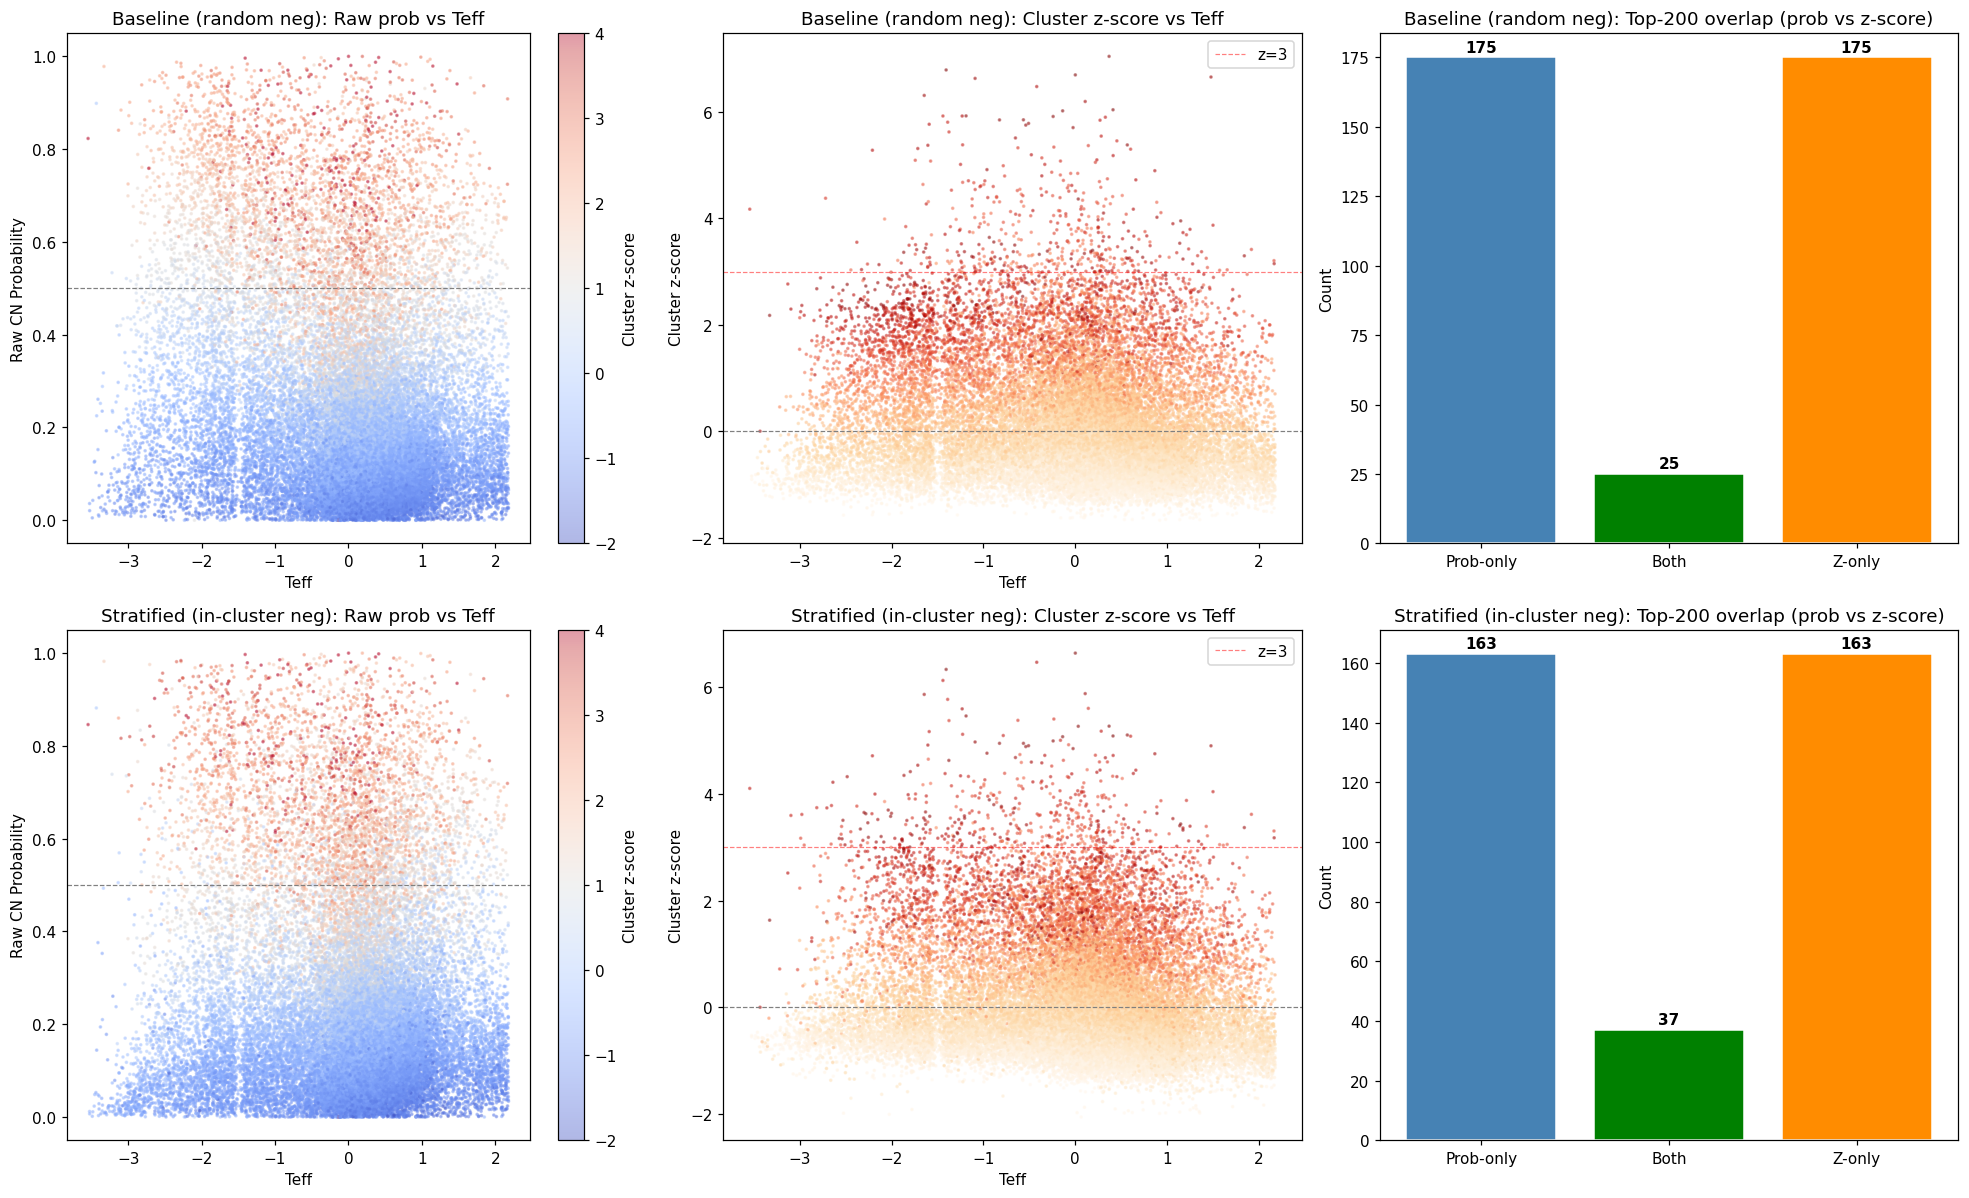

In [12]:
# Apply cluster-conditional scoring to BOTH baseline and stratified models
# Question: does ranking by cluster_z reduce parameter bias?

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for row, (df, name) in enumerate([
    (df_base, 'Baseline (random neg)'),
    (df_strat, 'Stratified (in-cluster neg)'),
]):
    # 1. Raw prob vs teff (colored by cluster_z)
    ax = axes[row, 0]
    sc = ax.scatter(df['teff'], df['cn_prob'], c=df['cluster_z'],
                    cmap='coolwarm', s=2, alpha=0.4, vmin=-2, vmax=4)
    ax.axhline(0.5, color='gray', ls='--', lw=0.8)
    ax.set_xlabel('Teff'); ax.set_ylabel('Raw CN Probability')
    ax.set_title(f'{name}: Raw prob vs Teff')
    plt.colorbar(sc, ax=ax, label='Cluster z-score')
    
    # 2. Cluster z-score vs teff
    ax = axes[row, 1]
    ax.scatter(df['teff'], df['cluster_z'], c=df['cn_prob'],
              cmap='OrRd', s=2, alpha=0.4, vmin=0, vmax=1)
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.axhline(3, color='red', ls='--', lw=0.8, alpha=0.5, label='z=3')
    ax.set_xlabel('Teff'); ax.set_ylabel('Cluster z-score')
    ax.set_title(f'{name}: Cluster z-score vs Teff')
    ax.legend()
    
    # 3. Top-200 comparison
    ax = axes[row, 2]
    top200_prob = set(df.nlargest(200, 'cn_prob').index)
    top200_z = set(df.nlargest(200, 'cluster_z').index)
    overlap = top200_prob & top200_z
    only_prob = len(top200_prob - top200_z)
    only_z = len(top200_z - top200_prob)
    
    bars = ax.bar(['Prob-only', 'Both', 'Z-only'], [only_prob, len(overlap), only_z],
                  color=['steelblue', 'green', 'darkorange'], edgecolor='white')
    for b, v in zip(bars, [only_prob, len(overlap), only_z]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(v), ha='center', fontweight='bold')
    ax.set_title(f'{name}: Top-200 overlap (prob vs z-score)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [13]:
# Quantitative: does cluster-z reduce parameter bias?
print('=' * 70)
print('PARAMETER BIAS: Raw Prob vs Cluster Z-Score (top-200)')
print('=' * 70)

for label, df in [('Baseline', df_base), ('Stratified', df_strat)]:
    print(f'\n--- {label} ---')
    for rank_by in ['cn_prob', 'cluster_z']:
        top200 = df.nlargest(200, rank_by)
        biases = {}
        for col in ['teff', 'logg', 'feh']:
            tv = top200[col].median()
            av = df[col].median()
            bias = abs((tv - av) / (abs(av) + 1e-8) * 100)
            biases[col] = bias
        avg_bias = np.mean(list(biases.values()))
        print(f'  Rank by {rank_by:12s}: avg param bias = {avg_bias:5.0f}%  (teff={biases["teff"]:.0f}%, logg={biases["logg"]:.0f}%, feh={biases["feh"]:.0f}%)')

PARAMETER BIAS: Raw Prob vs Cluster Z-Score (top-200)

--- Baseline ---
  Rank by cn_prob     : avg param bias =   538%  (teff=703%, logg=517%, feh=394%)
  Rank by cluster_z   : avg param bias =   225%  (teff=258%, logg=246%, feh=172%)

--- Stratified ---
  Rank by cn_prob     : avg param bias =   359%  (teff=437%, logg=399%, feh=241%)
  Rank by cluster_z   : avg param bias =   269%  (teff=385%, logg=312%, feh=110%)


## 7. Change C — Delta-Only Features\n
\n
Drop teff, logg, feh, CN3839, CN4142, CH4300. Keep only cluster-relative features:\n
`delta_CN3839, delta_CN4142, delta_CH4300, pca_1, pca_2, pca_3` (6-D)

In [14]:
# Select delta-only feature columns
delta_cols = ['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'pca_1', 'pca_2', 'pca_3']
delta_indices = [feat_names.index(c) for c in delta_cols]
print(f'Delta-only features: {delta_cols}')
print(f'Feature indices: {delta_indices}')

# Extract delta-only features from all arrays
X_train_pos_delta = X_train_pos[:, delta_indices]
neg_pool_delta = neg_pool[:, delta_indices]
X_val_delta = X_val[:, delta_indices]
X_cnstar_delta = X_cnstar_phys[:, delta_indices]
X_gcs_delta = X_gcs_phys[:, delta_indices]

# Augmented data also needs trimming (but augmentation was done on full 12-D)
# The augmentation changes only the feature values, indices stay valid
# Actually X_ft_aug is for full 12-D — need to redo augmentation on delta-only
X_ft_delta = X_ft_phys[:, delta_indices]
X_ft_aug_delta, _ = augment_spectra(
    X_ft_delta, np.arange(len(delta_cols), dtype=float),
    n_noise=12, n_rv=6, n_tilt=4, n_mixup=8, n_depth=6,
    noise_std=0.0025, random_seed=42,
)
X_train_pos_delta = X_ft_aug_delta[train_pos_mask[:len(X_ft_aug_delta)]]
X_val_delta = np.vstack([
    X_ft_aug_delta[val_pos_idx[:len(X_ft_aug_delta)]],
    neg_pool_delta[val_neg_idx[:len(neg_pool_delta)]],
])

print(f'X_train_pos_delta: {X_train_pos_delta.shape}')
print(f'neg_pool_delta:    {neg_pool_delta.shape}')

Delta-only features: ['delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'pca_1', 'pca_2', 'pca_3']
Feature indices: [6, 7, 8, 9, 10, 11]
X_train_pos_delta: (500, 6)
neg_pool_delta:    (33420, 6)


In [15]:
print('Training DELTA-ONLY (random negatives)...')
t0 = time.time()

models_delta, hist_delta = train_ensemble_with_sampler(
    X_train_pos_delta, neg_pool_delta, neg_clusters, pos_clusters,
    X_val_delta, y_val, n_models=5, base_seed=42,
    in_cluster_ratio=0.0, input_dim=len(delta_cols), device='cpu',
    verbose=True,
)
print(f'Delta-only trained in {time.time()-t0:.1f}s')

Training DELTA-ONLY (random negatives)...
  Model 1/5 (seed=42): 0 in-cluster + 500 out-cluster negatives
  Model 2/5 (seed=142): 0 in-cluster + 500 out-cluster negatives
  Model 3/5 (seed=242): 0 in-cluster + 500 out-cluster negatives
  Model 4/5 (seed=342): 0 in-cluster + 500 out-cluster negatives
  Model 5/5 (seed=442): 0 in-cluster + 500 out-cluster negatives
Delta-only trained in 25.6s


In [16]:
# Evaluate delta-only
probs_delta_unl, stds_delta_unl = ensemble_predict(models_delta, neg_pool_delta)
eval_delta_cnstar = evaluate_on_test(models_delta, X_cnstar_delta)
eval_delta_gcs = evaluate_on_test(models_delta, X_gcs_delta)

df_delta = pd.DataFrame({
    'cn_prob': probs_delta_unl,
    'cn_std': stds_delta_unl,
    'cluster': neg_clusters,
})
df_delta['cluster_z'] = cluster_z_score(probs_delta_unl, neg_clusters)
df_delta['teff'] = neg_meta['teff'].values
df_delta['logg'] = neg_meta['logg'].values
df_delta['feh'] = neg_meta['feh'].values
df_delta['delta_CN3839'] = neg_meta['delta_CN3839'].values

top200_delta = df_delta.nlargest(200, 'cn_prob')

print(f'Delta-only CNstar mean prob: {eval_delta_cnstar["mean_prob"]:.4f}')
print(f'Delta-only GCS mean prob:    {eval_delta_gcs["mean_prob"]:.4f}')
print(f'\n=== Delta-Only Parameter Bias (Top-200 vs All) ===')
for col in ['teff', 'logg', 'feh', 'delta_CN3839']:
    tv = top200_delta[col].median()
    av = df_delta[col].median()
    shift = (tv - av) / (abs(av) + 1e-8) * 100
    print(f'  {col:15s}: top200={tv:+.3f}  all={av:+.3f}  shift={shift:+5.0f}%')

Delta-only CNstar mean prob: 0.7840
Delta-only GCS mean prob:    0.2295

=== Delta-Only Parameter Bias (Top-200 vs All) ===
  teff           : top200=-0.345  all=+0.146  shift= -335%
  logg           : top200=-0.080  all=+0.196  shift= -141%
  feh            : top200=+0.693  all=+0.173  shift= +302%
  delta_CN3839   : top200=+3.663  all=-0.032  shift=+11689%


## 8. Final Comparison — All Approaches

In [17]:
# Summary table
results_summary = []

for name, df, eval_cn, eval_gcs, rank_col in [
    ('Baseline (random neg)', df_base, eval_base_cnstar, eval_base_gcs, 'cn_prob'),
    ('Baseline + z-score', df_base, eval_base_cnstar, eval_base_gcs, 'cluster_z'),
    ('A: Stratified neg', df_strat, eval_strat_cnstar, eval_strat_gcs, 'cn_prob'),
    ('A+B: Stratified + z-score', df_strat, eval_strat_cnstar, eval_strat_gcs, 'cluster_z'),
    ('C: Delta-only', df_delta, eval_delta_cnstar, eval_delta_gcs, 'cn_prob'),
    ('C + z-score', df_delta, eval_delta_cnstar, eval_delta_gcs, 'cluster_z'),
]:
    top200 = df.nlargest(200, rank_col)
    biases = {}
    for col in ['teff', 'logg', 'feh']:
        tv = top200[col].median()
        av = df[col].median()
        biases[col] = abs((tv - av) / (abs(av) + 1e-8) * 100)
    
    # Within-cluster corr with delta_CN3839
    wc_corrs = []
    for cid in np.unique(df['cluster']):
        cdf = df[df['cluster'] == cid]
        if len(cdf) >= 10:
            wc_corrs.append(cdf[rank_col].corr(cdf['delta_CN3839']))
    
    results_summary.append({
        'Method': name,
        'CNstar Prob': f"{eval_cn['mean_prob']:.3f}",
        'GCS Prob': f"{eval_gcs['mean_prob']:.3f}",
        'Avg Param Bias': f"{np.mean(list(biases.values())):.0f}%",
        'Teff Bias': f"{biases['teff']:.0f}%",
        'Within-Cluster r': f"{np.median(wc_corrs):.3f}",
    })

df_summary = pd.DataFrame(results_summary)
print('=' * 80)
print('FINAL COMPARISON: All Approaches')
print('=' * 80)
print(df_summary.to_string(index=False))

FINAL COMPARISON: All Approaches
                   Method CNstar Prob GCS Prob Avg Param Bias Teff Bias Within-Cluster r
    Baseline (random neg)       0.822    0.238           538%      703%            0.777
       Baseline + z-score       0.822    0.238           225%      258%            0.777
        A: Stratified neg       0.839    0.233           359%      437%            0.792
A+B: Stratified + z-score       0.839    0.233           269%      385%            0.792
            C: Delta-only       0.784    0.230           259%      335%            0.858
              C + z-score       0.784    0.230            56%       79%            0.858


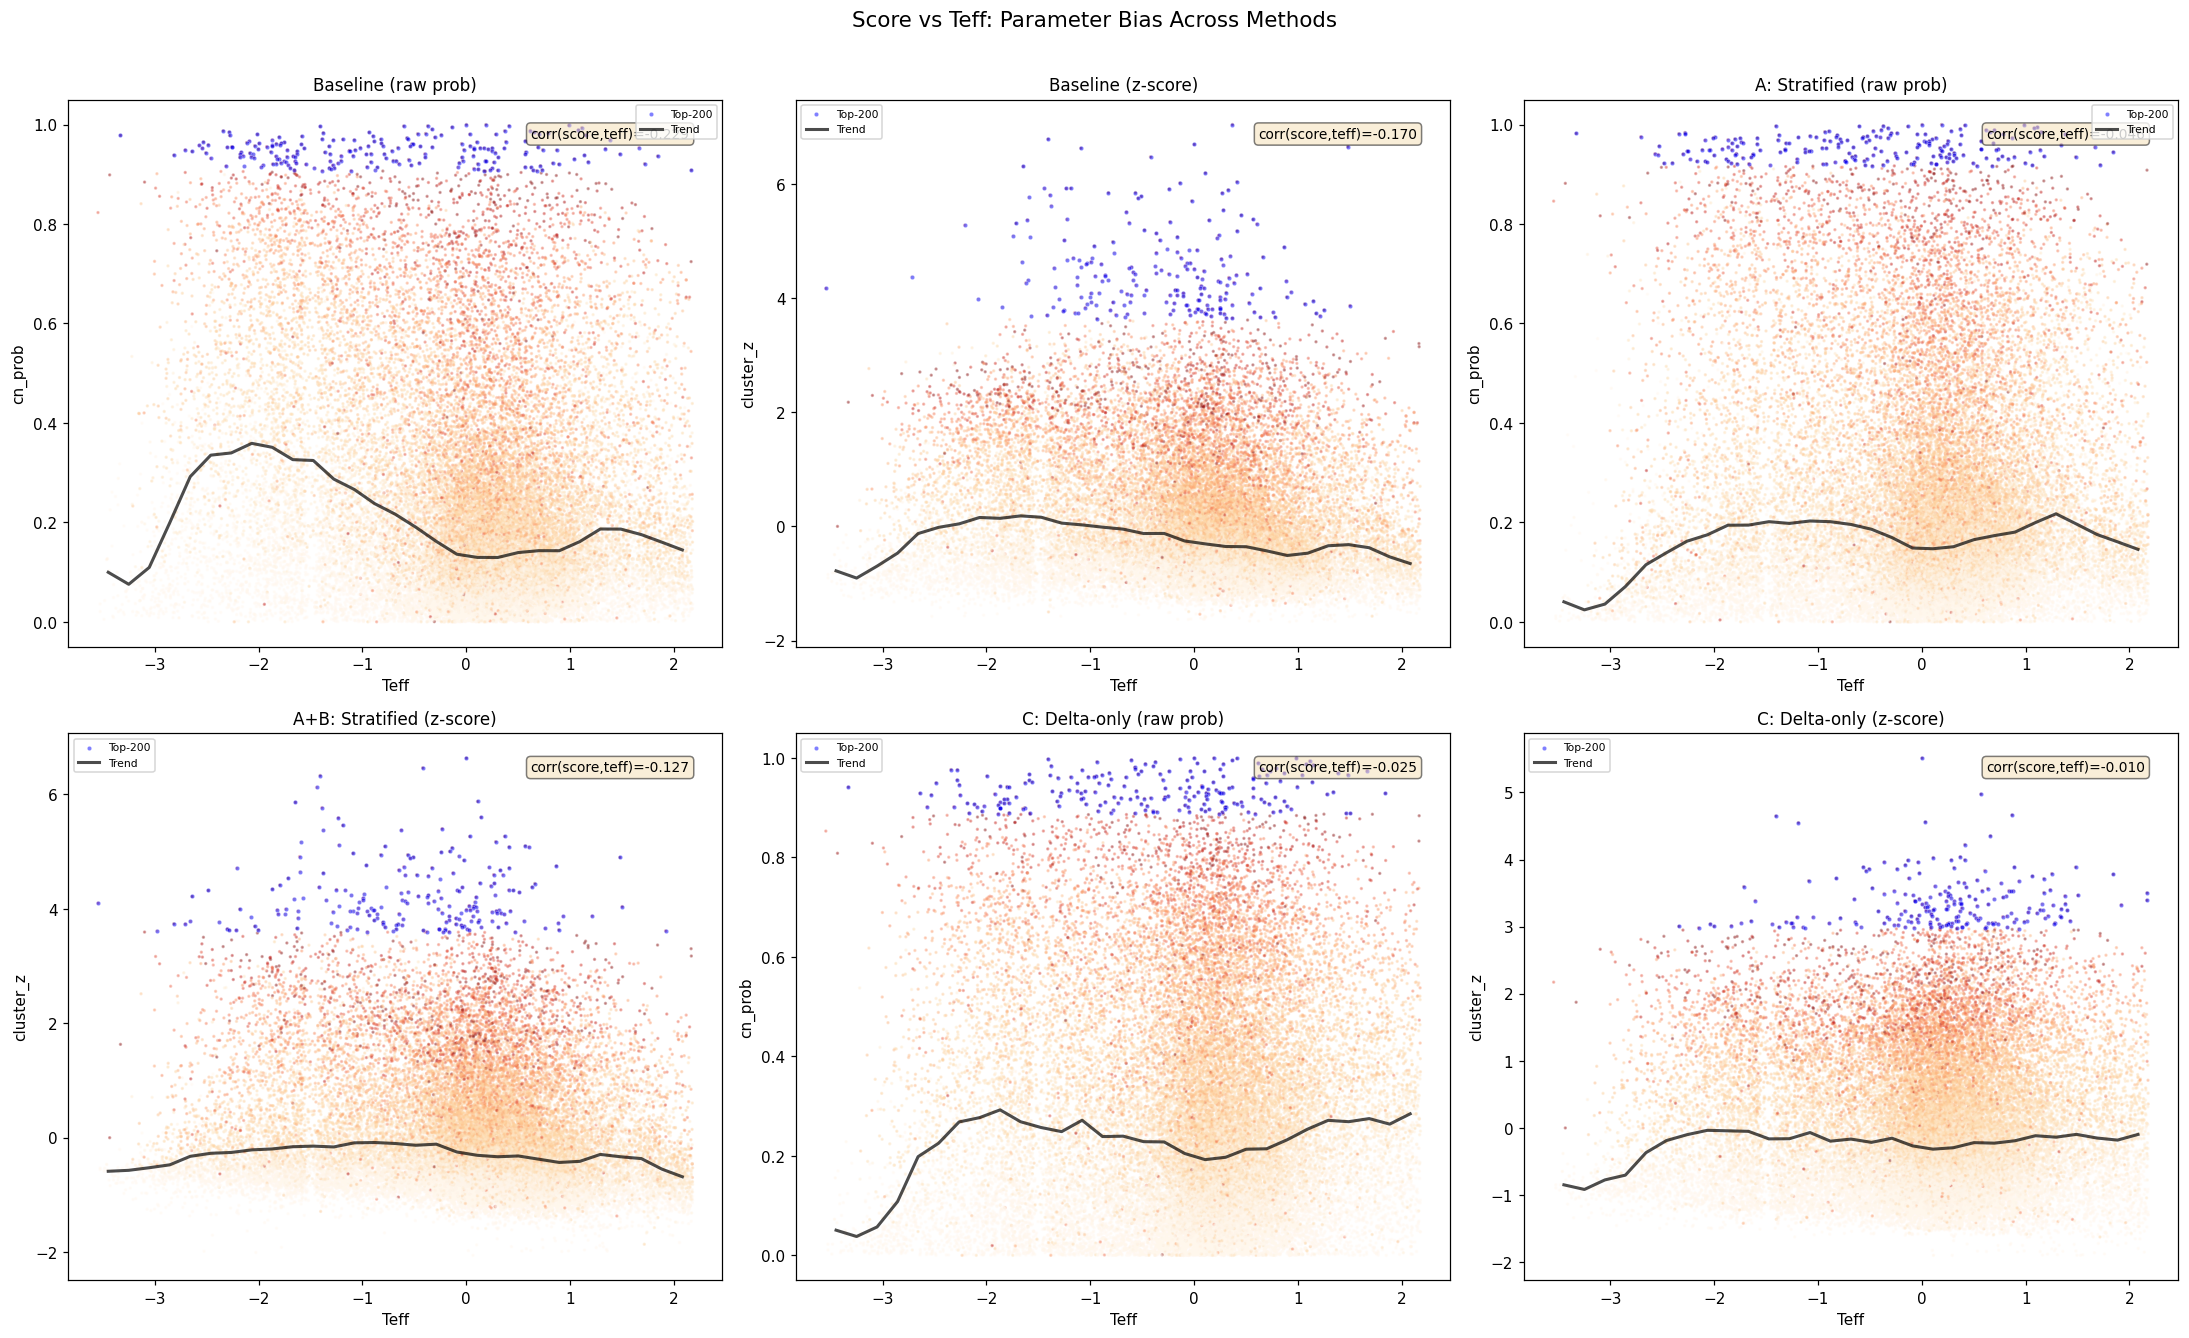

In [18]:
# Visual comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

configs = [
    ('Baseline (raw prob)', df_base, 'cn_prob'),
    ('Baseline (z-score)', df_base, 'cluster_z'),
    ('A: Stratified (raw prob)', df_strat, 'cn_prob'),
    ('A+B: Stratified (z-score)', df_strat, 'cluster_z'),
    ('C: Delta-only (raw prob)', df_delta, 'cn_prob'),
    ('C: Delta-only (z-score)', df_delta, 'cluster_z'),
]

for ax, (title, df, col) in zip(axes.flat, configs):
    top200 = df.nlargest(200, col)
    
    # Color by teff
    sc = ax.scatter(df['teff'], df[col], c=df['delta_CN3839'],
                    cmap='OrRd', s=1.5, alpha=0.3, vmin=-0.5, vmax=3)
    ax.scatter(top200['teff'], top200[col], c='blue', s=8, alpha=0.5,
              edgecolors='white', linewidth=0.3, label='Top-200')
    
    # Trend line
    from numpy.polynomial.polynomial import polyfit
    x_sort = np.argsort(df['teff'])
    x_vals = df['teff'].values[x_sort]
    y_vals = df[col].values[x_sort]
    # Binned median
    bins = np.linspace(x_vals.min(), x_vals.max(), 30)
    bin_meds = [np.median(y_vals[(x_vals >= bins[i]) & (x_vals < bins[i+1])]) for i in range(len(bins)-1)]
    bin_centers = [(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)]
    ax.plot(bin_centers, bin_meds, 'k-', lw=2, alpha=0.7, label='Trend')
    
    ax.set_xlabel('Teff'); ax.set_ylabel(col)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7)
    
    # Correlation
    r = df['teff'].corr(df[col])
    ax.text(0.95, 0.95, f'corr(score,teff)={r:+.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Score vs Teff: Parameter Bias Across Methods', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Top-200 overlap matrix:



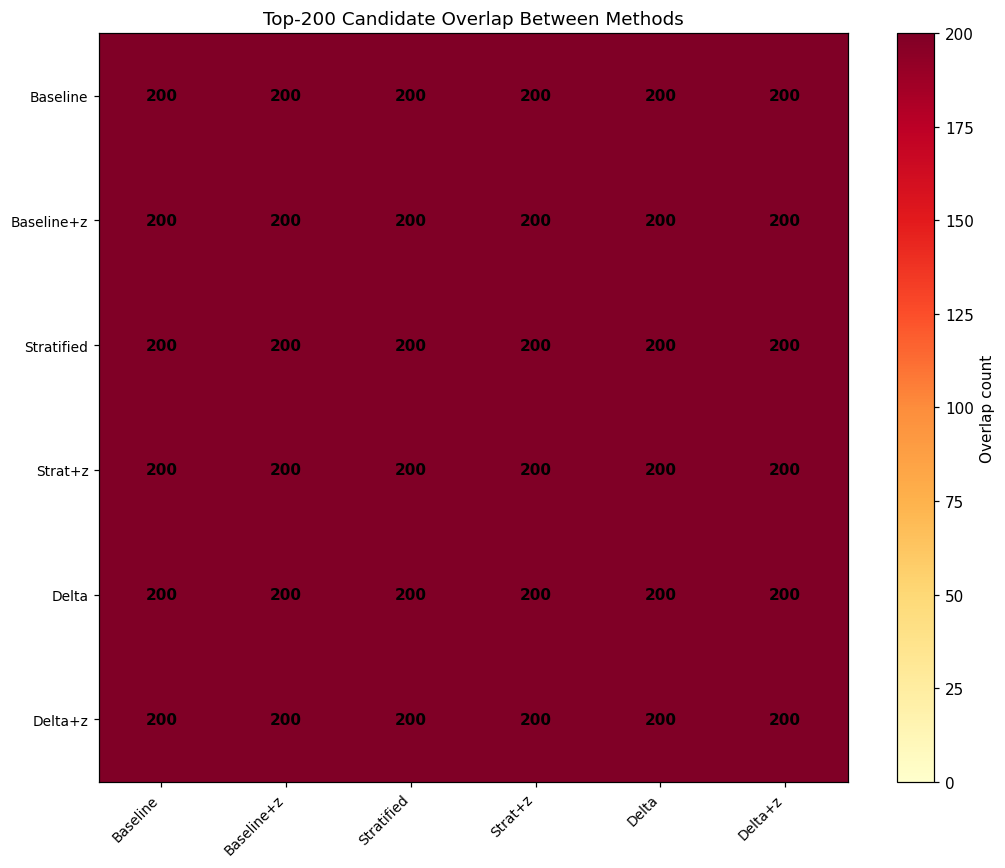

In [19]:
# Candidate overlap: how different are the top-200 lists?
print('Top-200 overlap matrix:')
print()

methods = {
    'Baseline': df_base.nlargest(200, 'cn_prob').index,
    'Baseline+z': df_base.nlargest(200, 'cluster_z').index,
    'Stratified': df_strat.nlargest(200, 'cn_prob').index,
    'Strat+z': df_strat.nlargest(200, 'cluster_z').index,
    'Delta': df_delta.nlargest(200, 'cn_prob').index,
    'Delta+z': df_delta.nlargest(200, 'cluster_z').index,
}

names = list(methods.keys())
overlap_matrix = np.zeros((len(names), len(names)))
for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        overlap_matrix[i, j] = len(methods[ni] & methods[nj])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(overlap_matrix, cmap='YlOrRd', vmin=0, vmax=200)
ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(names, fontsize=9)
for i in range(len(names)):
    for j in range(len(names)):
        v = int(overlap_matrix[i, j])
        ax.text(j, i, str(v), ha='center', va='center', fontweight='bold',
                color='white' if v < 100 else 'black')
ax.set_title('Top-200 Candidate Overlap Between Methods')
plt.colorbar(im, ax=ax, label='Overlap count')
plt.tight_layout()
plt.show()

## 9. Conclusion\n
\n
**Key metrics to judge success:**\n
\n
1. **Parameter bias reduction**: z-score ranking should reduce teff/logg/feh bias towards 0%\n
2. **CNstar prob maintained**: CNstar stars should still get high scores after correction\n
3. **Within-cluster correlation**: Should stay positive (>0.5) — the model still detects CN enhancement\n
4. **Top candidate diversity**: More clusters represented in top candidates = better\n
\n
**Best approach is the one with lowest parameter bias while maintaining CNstar detection.**